# CIFAR-10 Transfer Learning

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Load CIFAR-10

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

x_train, y_train = x_train[:5000], y_train[:5000]
x_test, y_test = x_test[:1000], y_test[:1000]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


# Normalize Data

In [3]:
# Flatten and normalize
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# Train classifier

In [4]:
# Train classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(x_train_flat, y_train)
y_pred = clf.predict(x_test_flat)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Classification Report

In [5]:
# Accuracy and report
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.30

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.30      0.32       103
           1       0.40      0.37      0.38        89
           2       0.26      0.27      0.27       100
           3       0.19      0.17      0.18       103
           4       0.19      0.23      0.21        90
           5       0.18      0.20      0.19        86
           6       0.37      0.31      0.34       112
           7       0.36      0.37      0.36       102
           8       0.38      0.47      0.42       106
           9       0.37      0.31      0.34       109

    accuracy                           0.30      1000
   macro avg       0.30      0.30      0.30      1000
weighted avg       0.31      0.30      0.30      1000



# CIFAR-10 labels

In [6]:
# CIFAR-10 labels
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# Confusion matrix

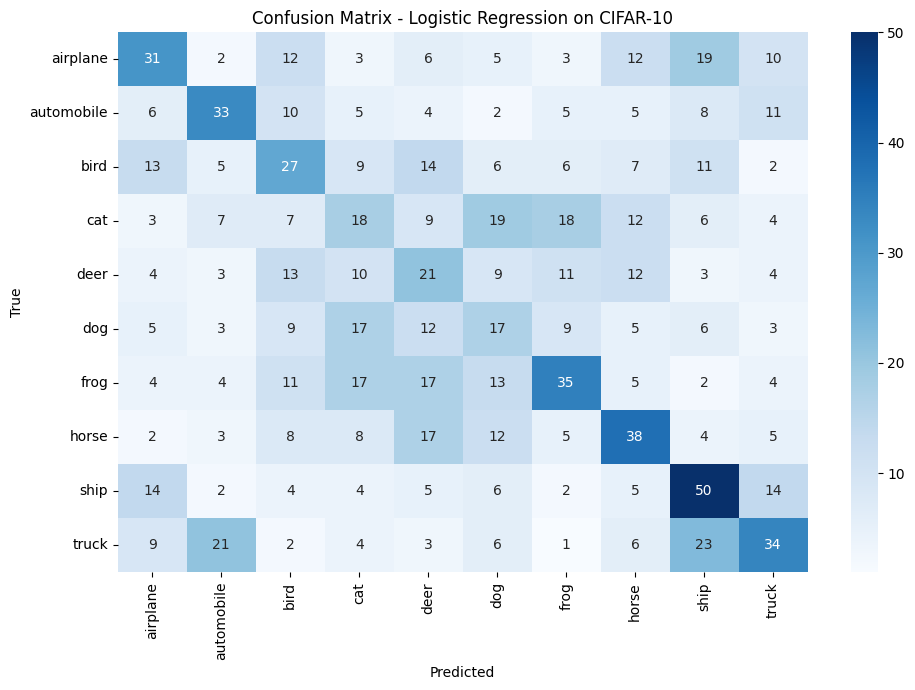

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Logistic Regression on CIFAR-10")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Correct vs Incorrect Predictions

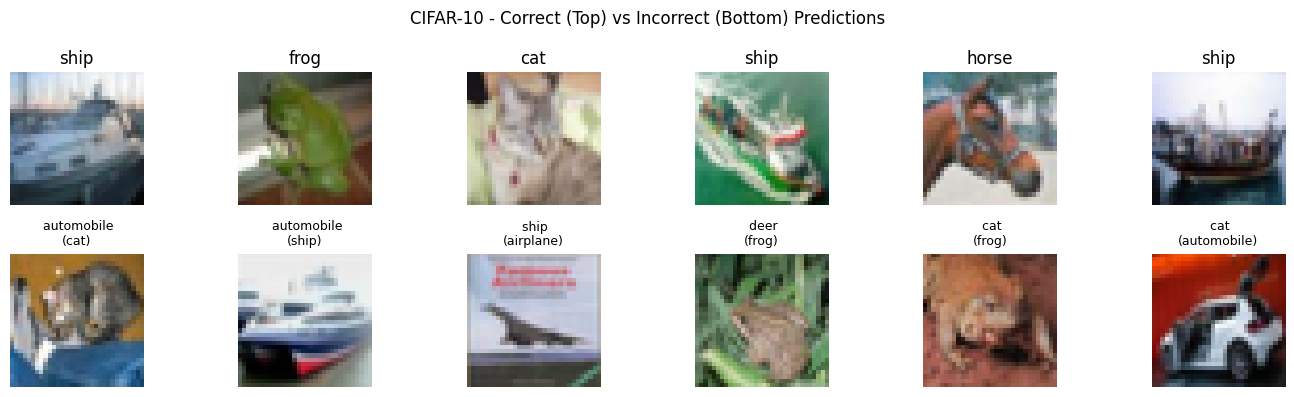

In [8]:
# Show correct vs incorrect predictions
correct = np.where(y_pred == y_test)[0][:6]
incorrect = np.where(y_pred != y_test)[0][:6]

plt.figure(figsize=(14, 4))
for idx, i in enumerate(correct):
    plt.subplot(2, 6, idx+1)
    plt.imshow(x_test[i])
    plt.title(f"{class_names[y_pred[i]]}")
    plt.axis("off")
for idx, i in enumerate(incorrect):
    plt.subplot(2, 6, idx+7)
    plt.imshow(x_test[i])
    plt.title(f" {class_names[y_pred[i]]}\n({class_names[y_test[i]]})", fontsize=9)
    plt.axis("off")
plt.suptitle("CIFAR-10 - Correct (Top) vs Incorrect (Bottom) Predictions")
plt.tight_layout()
plt.show()

# Per-class accuracy

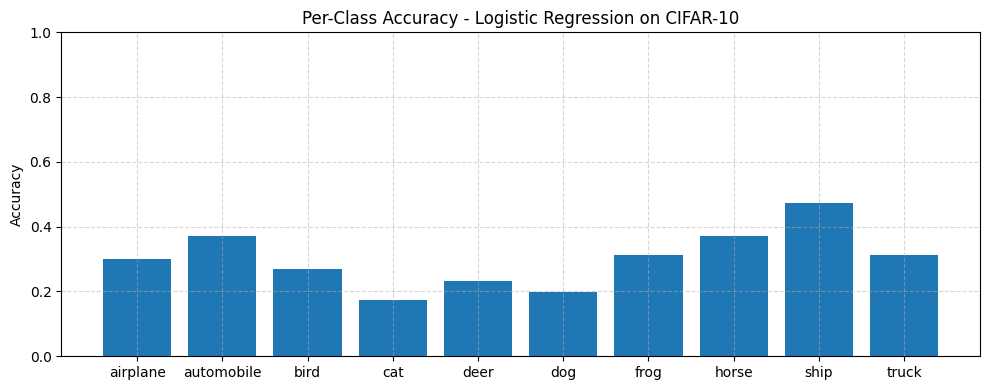

In [9]:
# Per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(10, 4))
plt.bar(class_names, per_class_accuracy)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy - Logistic Regression on CIFAR-10")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()